In [1]:
%load_ext autoreload
%autoreload 2

from noise import *
from pathlib import Path 
import json
from data import *
from trackers import *
from main import *

from networks.conditioning import *

import lpips

seed = 20
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_args(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    return args_dict


def load_exp(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    args_dict['size_network'] = "large"

    ctx = TrainingContext(**args_dict, step=step, key_remap=None, seed=None, dataloaders=dataloaders, writer=False)
    if log:
        print(f"{name}: retrieved model at step {ctx.step}")

    # Disable DataParallel (needed for Hessian computation)
    # ctx.model.network = ctx.model.network.module

    # Put in eval mode and disable gradients with respect to all parameters.
    ctx.model.eval()
    for p in ctx.model.parameters():
        p.requires_grad = False

    # Normalize energies.
    # ctx.network.network.log_normalization_constant = ctx.test_perf.log_normalization_constant

    return ctx

def get_sigmas(sigma_begin, sigma_end, num_classes, device, sigma_dis):
    if sigma_dist == 'geometric':
        sigmas = torch.tensor(
            np.exp(np.linspace(np.log(sigma_begin), np.log(sigma_end),
                               num_classes))).float().to(device)
    elif sigma_dist == 'uniform':
        sigmas = torch.tensor(
            np.linspace(sigma_begin, sigma_end, num_classes)
        ).float().to(device)

    else:
        raise NotImplementedError('sigma distribution not supported')

    return sigmas

torch.set_default_dtype(torch.float32)
    # torch.set_printoptions(precision=10, sci_mode=False)

# args = load_args("multigpu/inpainting_imagenet/denoiser_song_score_anisoEmb_groupNorm_mult_lr2e-4_lrdecay50000_1000warmup_128bs", step = "best")
args = load_args("multigpu/inpainting_celeba/denoiser_song_score_anisoEmb_groupNorm_mult_lr2e-4_lrdecay50000_1000warmup_128bs", step = "best")
# CovarianceEDMScoreMatching/models/multigpu/inpainting_imagenet/denoiser_song_score_anisoEmb_groupNorm_mult_lr2e-4_lrdecay50000_1000warmup_128bs
# args = load_args("multigpu/combined_cov_tworandvars/energy_ImageNet_songSmall_anisoEmb_groupNorm_lambda1_mult_lr1.5e-4_lrdecay50000_1000warmup_d2", step = "best")
# args = load_args("multigpu/combined_cov_tworandvars/energy_songWavelet_anisoEmb_groupNorm_lambda1_lr1.5e-4_lrdecay15000_1000warmup_d2", step = "last")
step = "last" #int(1e5)#"last"
ctxs = {
    # "energy-non-reg": load_exp("multigpu/combined_cov_tworandvars/energy_song_anisoEmb_groupNorm_lambda0_lr1.5e-4_lrdecay15000_1000warmup_d2", step = step),
    # "Energy-Dual": load_exp("multigpu/combined_cov_tworandvars/energy_song_anisoEmb_groupNorm_lambda1_mult_lr2e-4_lrdecay50000_1000warmup_d2", step = step),
    # "Energy-Dual-100k": load_exp("multigpu/combined_cov_tworandvars/energy_song_anisoEmb_groupNorm_lambda1_mult_lr2e-4_lrdecay50000_1000warmup_d2", step = 100000),
    # "Denoiser": load_exp("multigpu/combined_cov_tworandvars/denoiser_song_score_anisoEmb_groupNorm_mult_lr1.5e-4_lrdecay50000_1000warmup", step = step),
    # "Energy-Dual-larger": load_exp("multigpu/inpainting/energy_song_score_anisoEmb_groupNorm_lambda1_lr2e-4_lrdecay50000_1000warmup_d2_largerCov", step = "last"),
    # "Denoiser": load_exp("multigpu/inpainting_celeba/denoiser_songLarge_score_anisoEmb_groupNorm_mult_lr2e-4_lrdecay50000_1000warmup", step = step),
    "Denoiser": load_exp("multigpu/inpainting_celeba/denoiser_song_score_anisoEmb_groupNorm_mult_lr2e-4_lrdecay50000_1000warmup_128bs", step = step),
    # "Denoiser": load_exp("multigpu/inpainting_imagenet/denoiser_song_score_anisoEmb_groupNorm_mult_lr2e-4_lrdecay50000_1000warmup_128bs", step = step),
}

default_ctx = ctxs["Denoiser"]
device = default_ctx.device
dataset_info = default_ctx.dataset_info
d = dataset_info.dimension


# Load data
test_batch_size = 10
H = 64
CHW = 3 * H * H

train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=test_batch_size, num_workers=args["num_workers"], seed=2
)

images = next(iter(test_dataloader))  # load for testing things.

shape = (images[0].shape[0], CHW)
time_tracker: TimeTracker = TimeTracker()
time_tracker.switch("initialization")


loss_fn_alex = lpips.LPIPS(net='alex').cuda() # best forward scores

multigpu/inpainting_celeba/denoiser_song_score_anisoEmb_groupNorm_mult_lr2e-4_lrdecay50000_1000warmup_128bs: retrieved model at step 400000
Loading CelebA from train_64x64.pt...
✓ Loaded 182637 images with shape (182637, 64, 64, 3)
Loading CelebA from test_64x64.pt...
✓ Loaded 19962 images with shape (19962, 64, 64, 3)
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/lpips/weights/v0.1/alex.pth


## Song NCSV sampler

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0037529764..1.0009562].


None
Printing noisy image 0
Running Denoiser


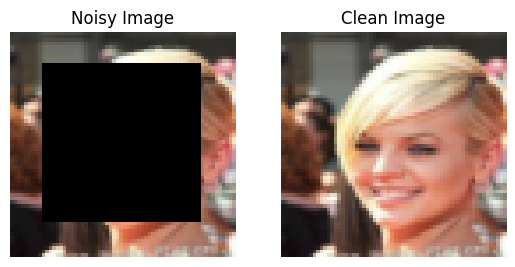

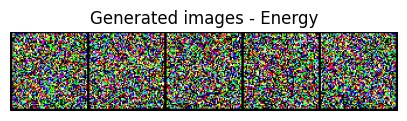

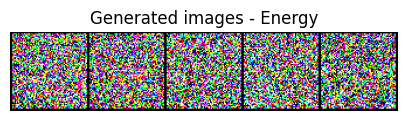

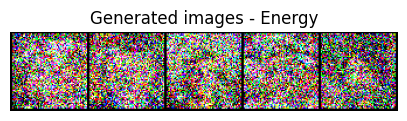

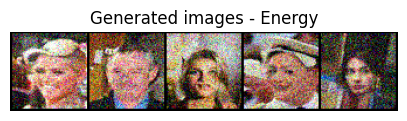

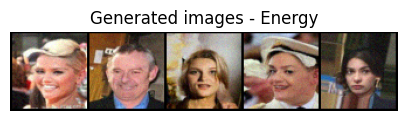

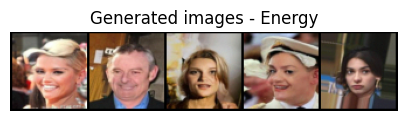

Execution time: 111.176531 seconds
Printing final image
MSE tensor(0.0204, device='cuda:0')
LPIPS tensor([[[[0.1224]]]], device='cuda:0', grad_fn=<DivBackward0>)


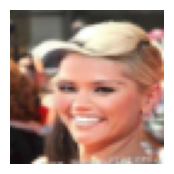

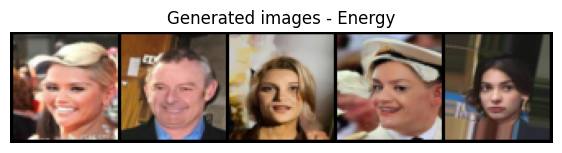

In [7]:
import time

def DPS_sampler(x_mod, y, H, mask, scorenet, sigmas, n_steps_each=200, batch_size=1,
               inp_mask_type="half", box_size=12, temp=1, snr=0.1):
    var_clean = 0
    iter_print_img = 0
    start_time = time.perf_counter()
    for c, sigma in enumerate(sigmas[:-2]):
        sigma_curr = sigmas[c]
        sigma_next = sigmas[c+1]
        
        # KEY FIX 1: Enable gradients only on x_mod, not intermediate tensors
        x_mod = x_mod.detach().requires_grad_(True)
        
        covariance = [spatial_corr_covariance_testing(
            spatial_size=H, box_size=box_size, var_box=sigma_curr**2, 
            device=device, var_clean=sigma_curr**2, 
            inp_mask_type=inp_mask_type, half_box_size=box_size, missing_indices_input=missing_indices
        )] * batch_size


        noise_level = NoiseLevel(variance=sigma_curr**2)
        input = ModelInput(noisy=x_mod, noise_level=noise_level, covariance=covariance)
        
        # KEY FIX 2: Forward pass with gradient tracking
        model_output = scorenet.forward(input, create_graph=False)
        grad = -model_output.data_score
        x0_pred = model_output.denoised
        
        # KEY FIX 3: Compute gradient efficiently
        residual = y - mask.apply_power(x0_pred, p=1)
        mat_norm = (residual.reshape(batch_size, -1) ** 2).sum(dim=1).sqrt()
        mat = (residual.reshape(batch_size, -1) ** 2).sum()
        
        # Compute gradient w.r.t. x_mod directly (backprop through network)
        grad_term = torch.autograd.grad(mat, x_mod, retain_graph=False)[0]
        
        # KEY FIX 4: Detach everything immediately after gradient computation
        grad = grad.detach()
        grad_term = grad_term.detach()
        mat_norm = mat_norm.detach()
        coeff = 0.05# / mat_norm.reshape(-1, 1, 1, 1)
        
        # KEY FIX 5: Move to no_grad context for update step
        with torch.no_grad():
            diff = sigma_curr**2 - sigma_next**2
            noise = torch.randn_like(x_mod)
            # Unconditional model #
            x_mod = x_mod + diff * grad + torch.sqrt(diff) * noise 
            # Guidance # 
            x_mod = x_mod - coeff * grad_term
        
        # KEY FIX 6: Clear cache periodically
        if c % 10 == 0:  # Every 10 steps
            torch.cuda.empty_cache()
        
        # Visualization code (unchanged)
        if iter_print_img % 200 == 0:
            with torch.no_grad():
                samples = torch.clamp(x_mod, 0.0, 1.0)
                nrow = 5
                grid = torchvision.utils.make_grid(samples[0:batch_size], nrow=nrow, 
                                                  padding=2, normalize=False)
                grid_np = grid.permute(1, 2, 0).cpu().numpy()
                plt.figure(figsize=(5, 5))
                plt.imshow(grid_np)
                plt.axis('off')
                plt.title("Generated images - Energy")
                plt.show()
        iter_print_img += 1

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Execution time: {elapsed_time:.6f} seconds")
    return [x_mod.detach().to('cpu')]
    


sigma_begin = 25
num_classes = 1200 #2400
sigma_dist = 'geometric'
sigma_end = 1e-3 #0.1e-2
img_size = H
batch_size = 5
sigma_box_init = sigma_begin**2
sigma_clean_init = 1e-3
inp_mask_type = "box"
box_size = 45 #19

sigmas = get_sigmas(sigma_begin, sigma_end, num_classes, device, sigma_dist)
total_pixels = img_size * img_size
n_missing = int(0.7 * total_pixels)
# missing_indices = torch.randperm(total_pixels, device=device)[:n_missing]
missing_indices = None # torch.load("../CovarianceGeneralEDMScoreMatching/missing_indices.pt")
print(missing_indices)

idx_img = 0 #torch.randint(0, images[0].shape[0], (1,)).item()
cov = spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=0, device=device, var_clean = 1, half_box_size = box_size, inp_mask_type=inp_mask_type, missing_indices_input=missing_indices)
clean_images = images[0][idx_img:idx_img+batch_size,:,:,:].cuda()#.repeat(batch_size,1,1,1)

x_init = cov.apply_power(clean_images, p = 1) + 1e-3 * torch.randn_like(images[0][idx_img:idx_img+batch_size,:,:,:]).cuda()
y = x_init[0:batch_size]

# kernel_size = 8
# kernel_std = 0.8
# cov = deblurring_covariance_from_shape(spatial_size=H, kernel_size=kernel_size, kernel_std=kernel_std, device=device, noise_level=1)
# # deblurring_id = sr_covariance_from_shape(spatial_size=H, kernel_size=4, device=device, noise_level=1)
# idx_img = 0 #torch.randint(0, images[0].shape[0], (1,)).item()
# x_deblur = cov.apply_power(images[0][idx_img:idx_img+batch_size,:,:,:].cuda(), p = -0.5)
# x_init = x_deblur + 0.01 * torch.randn_like(images[0][0:batch_size,:,:,:]).cuda()
# y = x_init[0:batch_size]
# clean_images = images[0][idx_img:idx_img+batch_size,:,:,:].cuda()#.repeat(batch_size,1,1,1)



x_init = torch.randn_like(images[0][0:batch_size,:,:,:]).cuda()

print("Printing noisy image", idx_img)

fig, ax = plt.subplots(1, 2)
ax[0].set_title('Noisy Image')
ax[1].set_title('Clean Image')
ax[0].imshow(y[0].permute(1,2,0).cpu().numpy())
ax[1].imshow(images[0][idx_img,:,:,:].permute(1,2,0).numpy())
# ax[2].imshow(x_init[0].permute(1,2,0).cpu().numpy())
ax[0].axis("off")
ax[1].axis("off")
# ax[2].axis("off")

seed = 10
temp = 1
step_lr = None
for model, ctx in ctxs.items():
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    print(f"Running {model}")
    x = DPS_sampler(x_init[0:batch_size], y, H, cov, ctx.model, sigmas, n_steps_each=None, batch_size=batch_size, inp_mask_type=inp_mask_type, temp = temp, box_size = box_size,
                                            snr = None)

    samples = torch.clamp(x[0], 0.0, 1.0)
    mse = torch.mean((clean_images - samples[0:batch_size].cuda())**2, dim=(-1, -2, -3)) 
    lpips = 0
    for ii in range(batch_size):
        lpips += loss_fn_alex(clean_images[ii:ii+1,:,:,:].cuda(),  samples[ii:ii+1].cuda())
    
    print("Printing final image")
    print("MSE", mse.mean())
    print("LPIPS", lpips / batch_size)
    
    plt.figure(figsize=(2,2))
    plt.imshow(samples[0].cpu().numpy().transpose(1, 2, 0))
    plt.axis('off')
    plt.show()

    # Save in dictonary

    samples = torch.clamp(x[0], 0.0, 1.0)
    nrow = 15
    grid = torchvision.utils.make_grid(samples, nrow=nrow, padding=2, normalize=False)
    grid_np = grid.permute(1, 2, 0).numpy()
     
    # Display the grid
    plt.figure(figsize=(7, 7)) # Adjust figure size as needed
    plt.imshow(grid_np)
    plt.axis('off') # Hide axes
    plt.title("Generated images - Energy")
    plt.show()

In [ ]:
Execution time: 110.827785 seconds
Printing final image
MSE tensor(0.0222, device='cuda:0')
LPIPS tensor([[[[0.0968]]]], device='cuda:0', grad_fn=<DivBackward0>)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00436883..0.9998513].


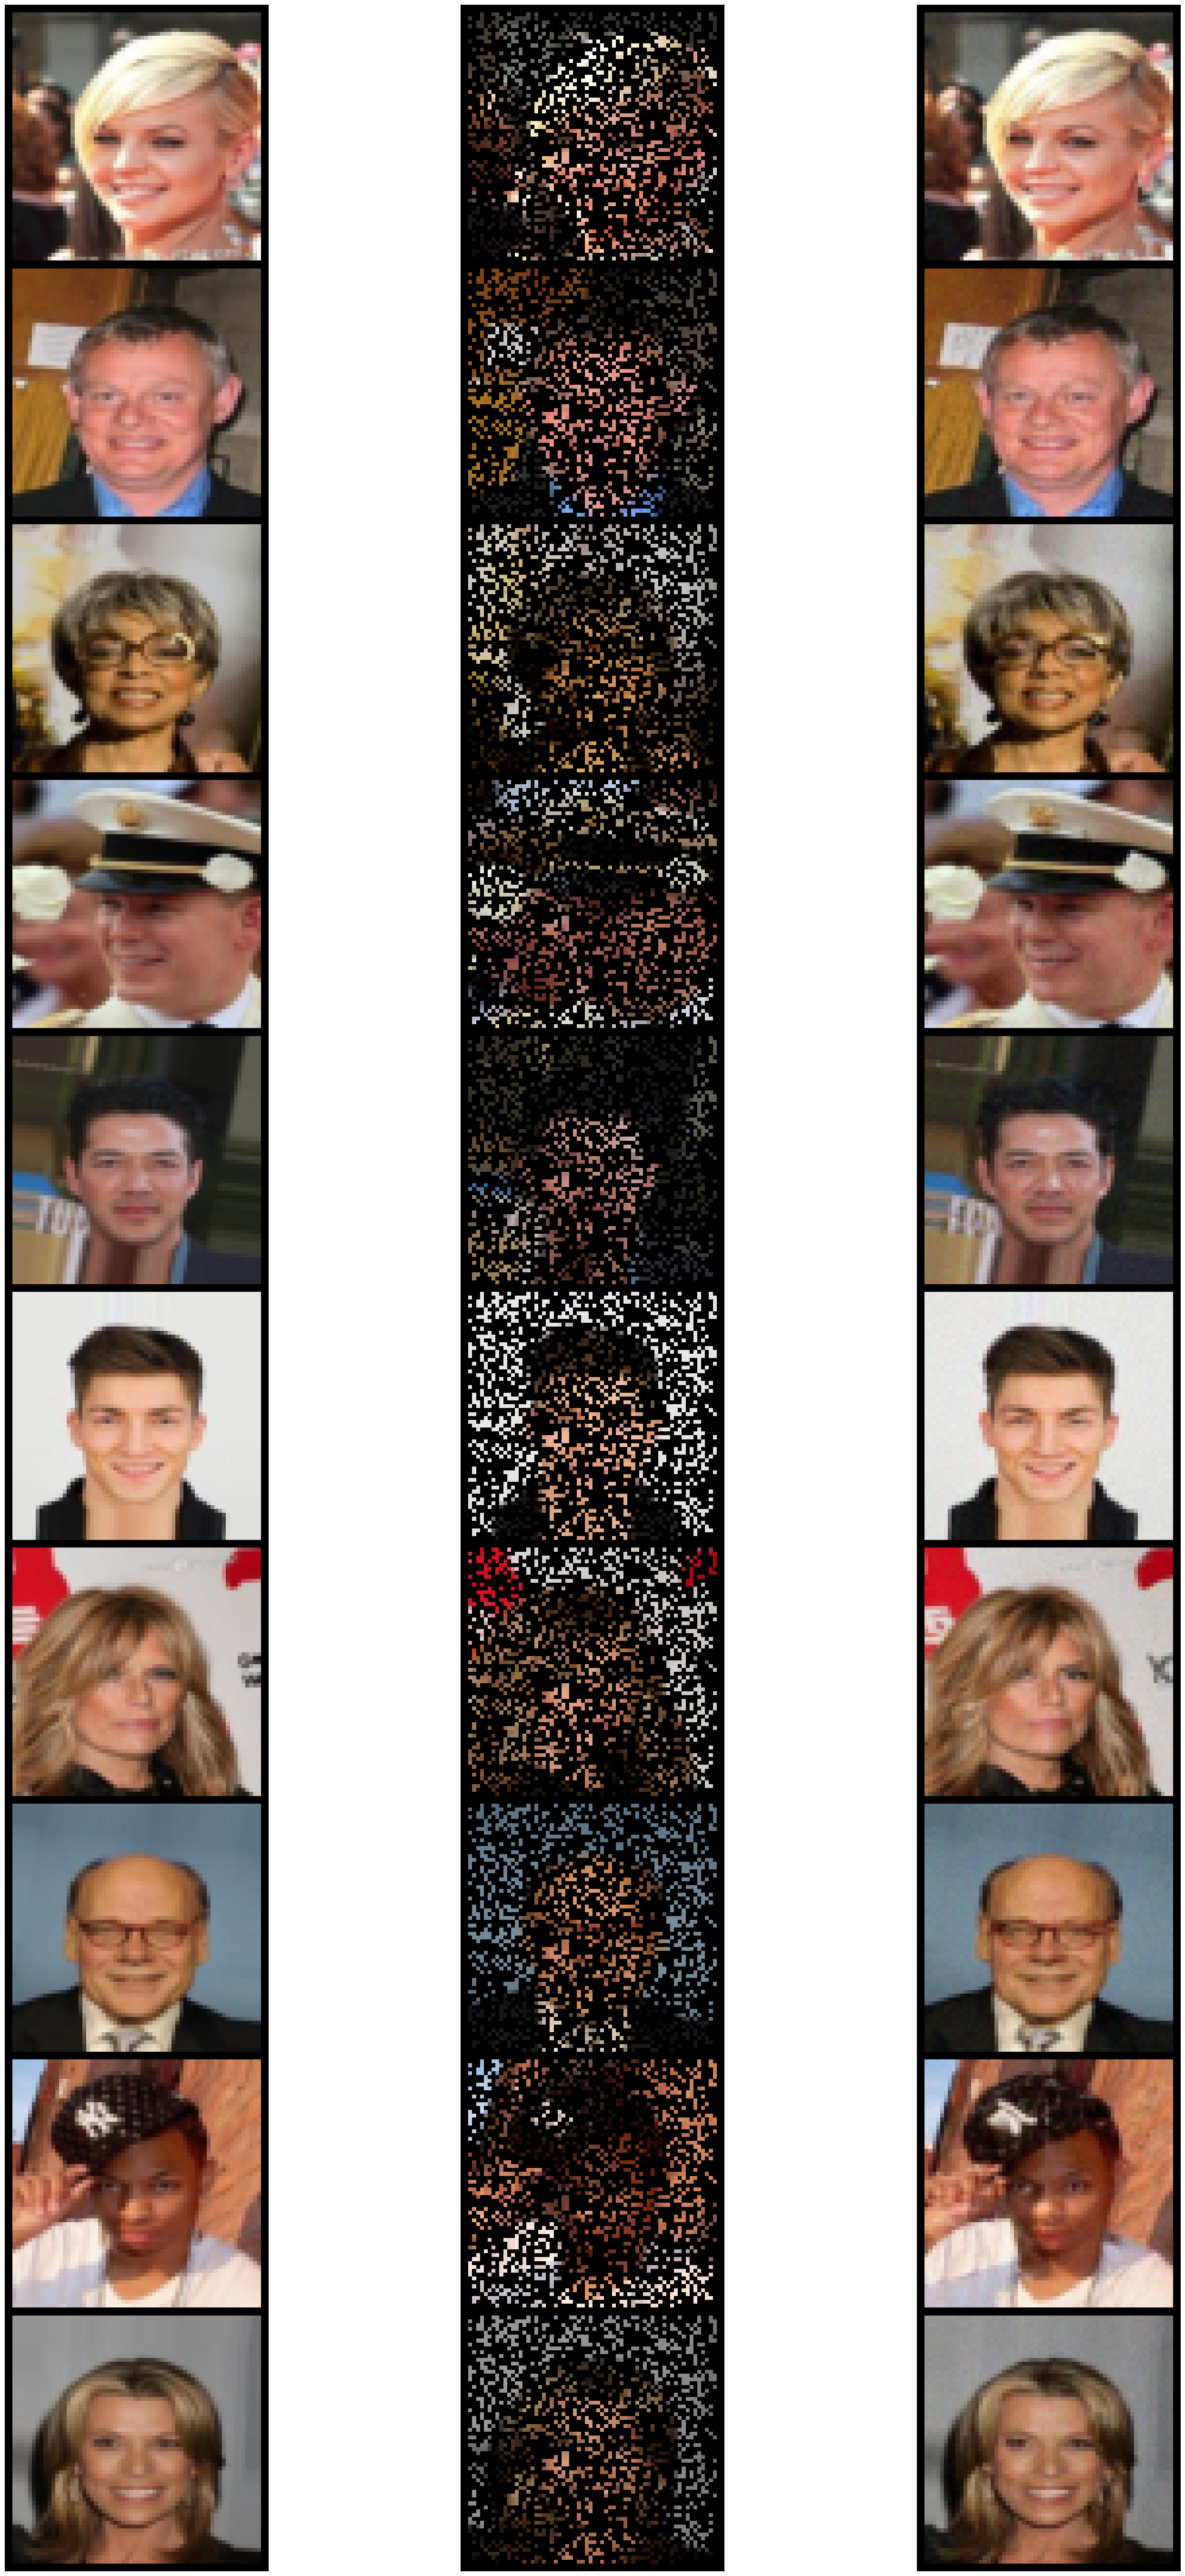

In [21]:
import torchvision

nrow = 1

grid = torchvision.utils.make_grid(images[0][idx_img:idx_img+batch_size,:,:,:].cuda().cpu(), nrow=nrow, padding=2)
grid_clean = grid.permute(1, 2, 0).numpy()

# deblurring_id = [deblurring_covariance_from_shape(spatial_size=H, kernel_size=kernel_size, kernel_std=kernel_std, device=device, noise_level=1)] * batch_size
# y_noisy_inv = apply_power_to_list_covariances(deblurring_id, x_init, p=-0.5).cpu()
# grid = torchvision.utils.make_grid(y_noisy_inv, nrow=nrow, padding=2)
grid = torchvision.utils.make_grid(y.cpu(), nrow=nrow, padding=2)
grid_np = grid.permute(1, 2, 0).numpy()

samples = torch.clamp(x[0], 0.0, 1.0)
grid = torchvision.utils.make_grid(samples, nrow=nrow, padding=2, normalize=False)
grid_np_energy = grid.permute(1, 2, 0).numpy()

# Display the grid
fig, ax = plt.subplots(1, 3,figsize=(35, 70))# Adjust figure size as needed
ax[0].imshow(grid_clean)
ax[0].axis('off') # Hide axes
ax[1].imshow(grid_np)
ax[1].axis('off') # Hide axes
ax[2].imshow(grid_np_energy)
ax[2].axis('off') # Hide axes
plt.savefig("samples.pdf")
plt.show()



# RED Diff

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0033243394..1.0008503].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.1010423..4.0398884].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.4597826..3.9503398].


Printing noisy image 0
Running Denoiser


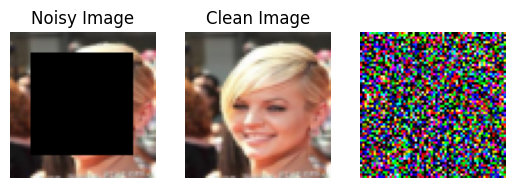

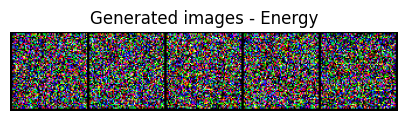

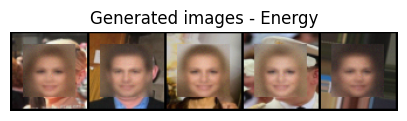

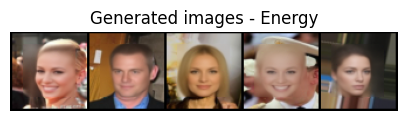

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0011798461..1.0004264].


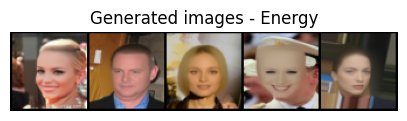

Printing final image
MSE tensor(0.0188)
LPIPS tensor([[[[0.1380]]]], device='cuda:0', grad_fn=<DivBackward0>)


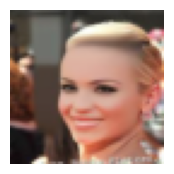

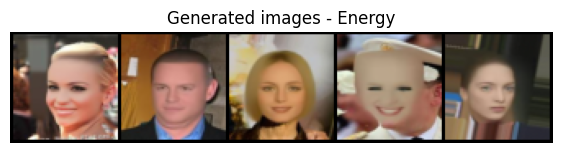

In [164]:
def reddiff(x_mod, y, H, mask, scorenet, sigmas, n_steps_each=200, batch_size=1,
               inp_mask_type="half", box_size=12, temp=1, snr=0.1):
    var_clean = 0
    iter_print_img = 0

    mu = x_mod.requires_grad_(True)

    #optimizer
    dtype = torch.FloatTensor
    optimizer = torch.optim.Adam([mu], lr=0.1, betas=(0.9, 0.99), weight_decay=0.0)   #original: 0.999
    
    for c, sigma in enumerate(sigmas[:-2]):
        sigma_curr = sigmas[c]
        sigma_next = sigmas[c+1]

        # Build covariance
        covariance = [spatial_corr_covariance_testing(
            spatial_size=H, box_size=box_size, var_box=sigma_curr**2, 
            device=device, var_clean=sigma_curr**2, 
            inp_mask_type=inp_mask_type, half_box_size=box_size
        )] * batch_size

        # Compute x_t
        noise_xt = torch.randn_like(images[0][idx_img:idx_img+batch_size,:,:,:]).cuda()
        x_t = mu + sigma_curr * noise_xt

        # Evaluate the score
        noise_level = NoiseLevel(variance=sigma_curr**2)
        input = ModelInput(noisy=x_t, noise_level=noise_level, covariance=covariance)
        model_output = scorenet.forward(input, create_graph=False)

        
        et = -(-model_output.data_score * sigma_curr)
    
        residual = y - mask.apply_power(mu, p=1)
        loss_obs = (residual**2).mean()/2
        loss_noise = torch.mul((et - noise_xt).detach(), mu).mean()

        snr_inv = sigma_curr/1  #1d torch tensor
    
        w_t = 0.1 * snr_inv   #0.25
        v_t = 1

        loss = w_t*loss_noise + v_t*loss_obs
        
        #adam step
        optimizer.zero_grad()  #initialize
        loss.backward()
        optimizer.step()
                
    
        # KEY FIX 6: Clear cache periodically
        if c % 10 == 0:  # Every 10 steps
            torch.cuda.empty_cache()
        
        # Visualization code (unchanged)
        if iter_print_img % 100 == 0:
            with torch.no_grad():
                samples = torch.clamp(x_mod, 0.0, 1.0)
                nrow = 5
                grid = torchvision.utils.make_grid(mu[0:20], nrow=nrow, 
                                                  padding=2, normalize=False)
                grid_np = grid.permute(1, 2, 0).cpu().numpy()
                plt.figure(figsize=(5, 5))
                plt.imshow(grid_np)
                plt.axis('off')
                plt.title("Generated images - Energy")
                plt.show()
        iter_print_img += 1
    
    return [mu.detach().to('cpu')]
    


sigma_begin = 25
num_classes = 400
sigma_dist = 'geometric'
sigma_end = 1e-3
img_size = H
batch_size = 5
sigma_box_init = sigma_begin**2
sigma_clean_init = 1e-3
inp_mask_type = "box"
box_size = 45 #19

sigmas = get_sigmas(sigma_begin, sigma_end, num_classes, device, sigma_dist)


idx_img = 0 #torch.randint(0, images[0].shape[0], (1,)).item()
cov = spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=0, device=device, var_clean = 1, half_box_size = box_size, inp_mask_type=inp_mask_type)
x_init = cov.apply_power(images[0][idx_img:idx_img+batch_size,:,:,:].cuda(), p = 1) + 1e-3 * torch.randn_like(images[0][idx_img:idx_img+batch_size,:,:,:]).cuda()
y = x_init[0:batch_size]

# kernel_size = 32
# kernel_std = 0.8
# cov = deblurring_covariance_from_shape(spatial_size=H, kernel_size=kernel_size, kernel_std=kernel_std, device=device, noise_level=1)
# # deblurring_id = sr_covariance_from_shape(spatial_size=H, kernel_size=4, device=device, noise_level=1)
# idx_img = 95 #torch.randint(0, images[0].shape[0], (1,)).item()
# x_deblur = cov.apply_power(images[0][idx_img:idx_img+batch_size,:,:,:].cuda(), p = -0.5)
# x_init = x_deblur + 1e-7 * torch.randn_like(images[0][0:batch_size,:,:,:]).cuda()
# y = x_init[0:batch_size]


x_init = torch.randn_like(images[0][0:batch_size,:,:,:]).cuda()

print("Printing noisy image", idx_img)

fig, ax = plt.subplots(1, 3)
ax[0].set_title('Noisy Image')
ax[1].set_title('Clean Image')
ax[0].imshow(y[0].permute(1,2,0).cpu().numpy())
ax[1].imshow(images[0][idx_img,:,:,:].permute(1,2,0).numpy())
ax[2].imshow(x_init[0].permute(1,2,0).cpu().numpy())
ax[0].axis("off")
ax[1].axis("off")
ax[2].axis("off")

seed = 5
temp = 1
step_lr = None
for model, ctx in ctxs.items():
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    print(f"Running {model}")
    x = reddiff(x_init[0:batch_size], y, H, cov, ctx.model, sigmas, n_steps_each=None, batch_size=batch_size, inp_mask_type=inp_mask_type, temp = temp, box_size = box_size,
                                            snr = None)

    samples = torch.clamp(x[0], 0.0, 1.0)
    mse = torch.mean((images[0][idx_img:idx_img+batch_size,:,:,:] - samples[0:batch_size])**2, dim=(-1, -2, -3)) 
    lpips = 0
    for ii in range(batch_size):
        lpips += loss_fn_alex(images[0][ii+idx_img:ii+idx_img+1,:,:,:].cuda(),  samples[ii:ii+1].cuda())
    
    print("Printing final image")
    print("MSE", mse.mean())
    print("LPIPS", lpips / batch_size)
    
    plt.figure(figsize=(2,2))
    plt.imshow(samples[0].cpu().numpy().transpose(1, 2, 0))
    plt.axis('off')
    plt.show()

    # Save in dictonary

    samples = torch.clamp(x[0], 0.0, 1.0)
    nrow = 15
    grid = torchvision.utils.make_grid(samples, nrow=nrow, padding=2, normalize=False)
    grid_np = grid.permute(1, 2, 0).numpy()
     
    # Display the grid
    plt.figure(figsize=(7, 7)) # Adjust figure size as needed
    plt.imshow(grid_np)
    plt.axis('off') # Hide axes
    plt.title("Generated images - Energy")
    plt.show()

# DAPS

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.004362678..1.0014303].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.7984269..3.7229683].


Printing noisy image 0
Running Denoiser


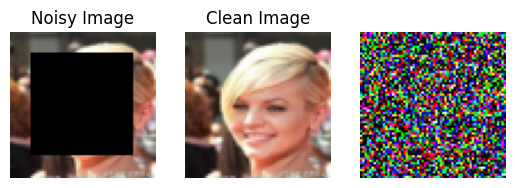

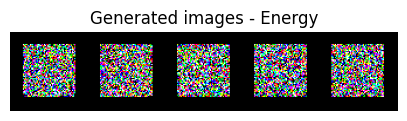

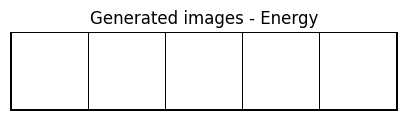

KeyboardInterrupt: 

In [51]:
def ODE_flow(x_mod, H, scorenet, sigmas, c, batch_size=1,
               inp_mask_type="half", box_size=12, temp=1):

    for c_ode, sigma in enumerate(sigmas[:-1]):
        sigma_curr = sigmas[c_ode]
        sigma_next = sigmas[c_ode + 1]
        
        x_mod = x_mod.detach()
        
        covariance = [spatial_corr_covariance_testing(
            spatial_size=H, box_size=box_size, var_box=sigma_curr**2, 
            device=device, var_clean=sigma_curr**2, 
            inp_mask_type=inp_mask_type, half_box_size=H
        )] * batch_size


        noise_level = NoiseLevel(variance=sigma_curr**2)
        input = ModelInput(noisy=x_mod, noise_level=noise_level, covariance=covariance)
        
        model_output = scorenet.forward(input, create_graph=False)
        grad = -model_output.data_score
        
        with torch.no_grad():
            # noise = torch.randn_like(x_mod)
            # diff = sigma_curr**2 - sigma_next**2
            # x_mod = x_mod + 0.5 * diff * grad #+ torch.sqrt(diff) * noise 
            x0_hat = x_mod + sigma_curr**2 * grad
            d = (x_mod - x0_hat) / sigma_curr
            x_mod = x_mod + (sigma_next - sigma_curr) * d
        
    return x_mod


def DAPS_sampler(x_mod, y, H, mask, scorenet, sigmas, num_steps_langevin=100, batch_size=1,
               inp_mask_type="half", box_size=12, temp=1, lr_langevin=2e-8):
    var_clean = 0
    iter_print_img = 0
    
    for c, sigma in enumerate(sigmas[:-2]):
        
        # Run the ODE to get x_0
        sigmas_ODE = get_sigmas(sigma.detach().cpu().numpy(), sigmas[-1].detach().cpu().numpy(), 5, device, sigma_dist)
        x_pred = ODE_flow(x_mod, H, scorenet, sigmas_ODE, c, batch_size, inp_mask_type, box_size, temp)

        # -- Run Langevin sampling
        x_cond_pred = x_pred.clone().detach().requires_grad_(True)
        # Parameters
        r_t = (2 * sigmas[c] ** 2)
        p = 1
        ratio = c/len(sigmas)
        coeff = (1  + ratio * (0.01 * (1/p) - 1)) ** p * lr_langevin

        for _ in range(num_steps_langevin):
            
            # Measurement residual
            residual = mask.apply_power(x_cond_pred, p=1) - y
            residual_y_norm = (residual.reshape(batch_size, -1) ** 2).sum() / (2 * 1e-3 ** 2) #1e-3 is the noise level of the measurement

            # Prior residual
            residual_prior = (x_cond_pred - x_pred.detach()) 
            residual_prior_norm = (residual_prior.reshape(batch_size, -1) ** 2).sum() / r_t

            # Aggregate
            loss = residual_y_norm + residual_prior_norm
            grad = torch.autograd.grad(loss, x_cond_pred, retain_graph=False)[0]
            
            # Update
            noise = torch.randn_like(x_pred)
            x_cond_pred = x_cond_pred - coeff * (grad) + np.sqrt(2 * coeff) * noise

        # Sample a noisy version of the next noise level
        x_mod = x_cond_pred + sigmas[c+1] * torch.randn_like(x_cond_pred)
        
        # Visualization code (unchanged)
        if c % 10 == 0:
            torch.cuda.empty_cache()
            with torch.no_grad():
                samples = torch.clamp(x_mod, 0.0, 1.0)
                nrow = 5
                grid = torchvision.utils.make_grid(samples[0:20], nrow=nrow, 
                                                  padding=2, normalize=False)
                grid_np = grid.permute(1, 2, 0).cpu().numpy()
                plt.figure(figsize=(5, 5))
                plt.imshow(grid_np)
                plt.axis('off')
                plt.title("Generated images - Energy")
                plt.show()
                
    return [x_cond_pred.detach().to('cpu')]



sigma_begin = 25
num_classes = 250 #2400
sigma_dist = 'geometric'
sigma_end = 1e-3 #0.1e-2
img_size = H
batch_size = 5
sigma_box_init = sigma_begin**2
sigma_clean_init = 1e-3
inp_mask_type = "box"
box_size = 45 #19
lr_langevin = 3e-6

sigmas = get_sigmas(sigma_begin, sigma_end, num_classes, device, sigma_dist)


idx_img = 0 #torch.randint(0, images[0].shape[0], (1,)).item()
cov = spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=0, device=device, var_clean = 1, half_box_size = box_size, inp_mask_type=inp_mask_type)
clean_images = images[0][idx_img:idx_img+batch_size,:,:,:].cuda()#.repeat(batch_size,1,1,1)

x_init = cov.apply_power(clean_images, p = 1) + 1e-3 * torch.randn_like(images[0][idx_img:idx_img+batch_size,:,:,:]).cuda()
y = x_init[0:batch_size]

x_init = torch.randn_like(images[0][0:batch_size,:,:,:]).cuda()

print("Printing noisy image", idx_img)

fig, ax = plt.subplots(1, 3)
ax[0].set_title('Noisy Image')
ax[1].set_title('Clean Image')
ax[0].imshow(y[0].permute(1,2,0).cpu().numpy())
ax[1].imshow(images[0][idx_img,:,:,:].permute(1,2,0).numpy())
ax[2].imshow(x_init[0].permute(1,2,0).cpu().numpy())
ax[0].axis("off")
ax[1].axis("off")
ax[2].axis("off")

seed = 20
temp = 1
step_lr = None
for model, ctx in ctxs.items():
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    print(f"Running {model}")
    x = DAPS_sampler(x_init[0:batch_size], y, H, cov, ctx.model, sigmas, batch_size=batch_size, inp_mask_type=inp_mask_type, temp = temp, box_size = box_size,
                                            lr_langevin = lr_langevin)

    samples = torch.clamp(x[0], 0.0, 1.0)
    mse = torch.mean((clean_images - samples[0:batch_size].cuda())**2, dim=(-1, -2, -3)) 
    lpips = 0
    for ii in range(batch_size):
        lpips += loss_fn_alex(clean_images[ii:ii+1,:,:,:].cuda(),  samples[ii:ii+1].cuda())
    
    print("Printing final image")
    print("MSE", mse.mean())
    print("LPIPS", lpips / batch_size)
    
    plt.figure(figsize=(2,2))
    plt.imshow(samples[0].cpu().numpy().transpose(1, 2, 0))
    plt.axis('off')
    plt.show()

    # Save in dictonary

    samples = torch.clamp(x[0], 0.0, 1.0)
    nrow = 15
    grid = torchvision.utils.make_grid(samples, nrow=nrow, padding=2, normalize=False)
    grid_np = grid.permute(1, 2, 0).numpy()
     
    # Display the grid
    plt.figure(figsize=(7, 7)) # Adjust figure size as needed
    plt.imshow(grid_np)
    plt.axis('off') # Hide axes
    plt.title("Generated images - Energy")
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0027923083..1.0009562].


None
Printing noisy image 0
Running Denoiser


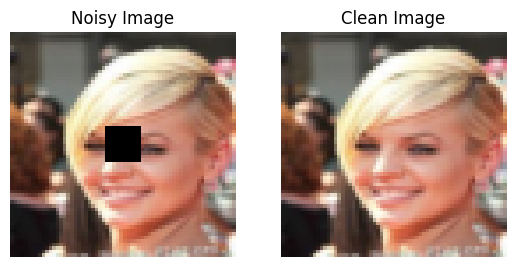

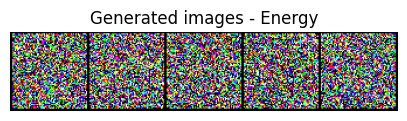

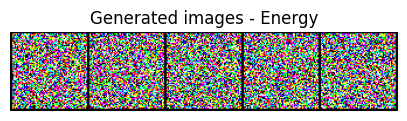

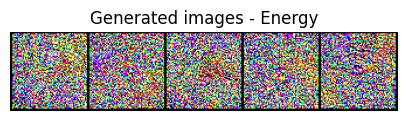

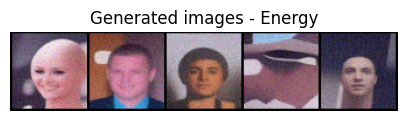

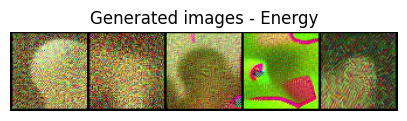

KeyboardInterrupt: 

In [28]:
        # delta = prev_sigma ** 2 - sigma ** 2

        # # Calculate added noise variance based on sampling algorithm.
        # if algo == "zahra":
        #     # Zahra: calculated as a fraction of the removed noise (slightly dubious)
        #     h = delta / prev_sigma ** 2
        #     gamma = prev_sigma ** 2 * ((1 - (beta * h)) ** 2 - (1 - h) ** 2)


import time

def zahras_sampler(x_mod, y, H, mask, scorenet, sigmas, n_steps_each=200, batch_size=1,
               inp_mask_type="half", box_size=12, temp=1, snr=0.1, beta = 0.0001, h_0 = 0.001):
    var_clean = 0
    iter_print_img = 0
    start_time = time.perf_counter()
    for c, sigma in enumerate(sigmas[:-2]):
        sigma_curr = sigmas[c]
        sigma_next = sigmas[c+1]
        
        # KEY FIX 1: Enable gradients only on x_mod, not intermediate tensors
        x_mod = x_mod.detach().requires_grad_(True)
        
        covariance = [spatial_corr_covariance_testing(
            spatial_size=H, box_size=box_size, var_box=sigma_curr**2, 
            device=device, var_clean=sigma_curr**2, 
            inp_mask_type=inp_mask_type, half_box_size=box_size, missing_indices_input=missing_indices
        )] * batch_size


        noise_level = NoiseLevel(variance=sigma_curr**2)
        input = ModelInput(noisy=x_mod, noise_level=noise_level, covariance=covariance)
        
        # KEY FIX 2: Forward pass with gradient tracking
        model_output = scorenet.forward(input, create_graph=False)
        grad = -model_output.data_score
        x0_pred = model_output.denoised
        
        # KEY FIX 3: Compute gradient efficiently
        residual = y - mask.apply_power(x0_pred, p=1)
        mat_norm = (residual.reshape(batch_size, -1) ** 2).sum(dim=1).sqrt()
        mat = (residual.reshape(batch_size, -1) ** 2).sum()
        
        # Compute gradient w.r.t. x_mod directly (backprop through network)
        grad_term = torch.autograd.grad(mat, x_mod, retain_graph=False)[0]
        
        # KEY FIX 4: Detach everything immediately after gradient computation
        grad = grad.detach()
        grad_term = grad_term.detach()

        diff = sigma_curr**2 - sigma_next**2
        h_t = diff / sigma_curr ** 2
        gamma = sigma_curr ** 2 * ((1 - (beta * h_t)) ** 2 - (1 - h_t) ** 2)

        # h_t = h_0 * (c+1) / (1 + h_0 * c)
        # norm_denoiser = torch.norm(x0_pred, p = 2, dim = (1,2,3))
        # sigma_t = torch.sqrt(norm_denoiser.mean() / d)
        # gamma = sigma_t ** 2 * ((1 - (beta * h_t)) ** 2 - (1 - h_t) ** 2)
        # KEY FIX 5: Move to no_grad context for update step
        with torch.no_grad():
            noise = torch.randn_like(x_mod)
            # Unconditional model #
            x_mod = x_mod + h_t * grad + torch.sqrt(gamma) * noise 
            # Guidance # 
            x_mod = x_mod - h_t * grad_term
        
        # KEY FIX 6: Clear cache periodically
        if c % 10 == 0:  # Every 10 steps
            torch.cuda.empty_cache()
        
        # Visualization code (unchanged)
        if iter_print_img % 200 == 0:
            with torch.no_grad():
                samples = torch.clamp(x_mod, 0.0, 1.0)
                nrow = 5
                grid = torchvision.utils.make_grid(samples[0:batch_size], nrow=nrow, 
                                                  padding=2, normalize=False)
                grid_np = grid.permute(1, 2, 0).cpu().numpy()
                plt.figure(figsize=(5, 5))
                plt.imshow(grid_np)
                plt.axis('off')
                plt.title("Generated images - Energy")
                plt.show()
        iter_print_img += 1

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Execution time: {elapsed_time:.6f} seconds")
    return [x_mod.detach().to('cpu')]
    


sigma_begin = 20
num_classes = 1000 #2400
sigma_dist = 'geometric'
sigma_end = 1e-2 #0.1e-2
img_size = H
batch_size = 5
sigma_box_init = sigma_begin**2
sigma_clean_init = 1e-3
inp_mask_type = "box"
box_size = 10 #19

sigmas = get_sigmas(sigma_begin, sigma_end, num_classes, device, sigma_dist)
total_pixels = img_size * img_size
n_missing = int(0.7 * total_pixels)
# missing_indices = torch.randperm(total_pixels, device=device)[:n_missing]
missing_indices = None # torch.load("../CovarianceGeneralEDMScoreMatching/missing_indices.pt")
print(missing_indices)

idx_img = 0 #torch.randint(0, images[0].shape[0], (1,)).item()
cov = spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=0, device=device, var_clean = 1, half_box_size = box_size, inp_mask_type=inp_mask_type, missing_indices_input=missing_indices)
clean_images = images[0][idx_img:idx_img+batch_size,:,:,:].cuda()#.repeat(batch_size,1,1,1)

x_init = cov.apply_power(clean_images, p = 1) + 1e-3 * torch.randn_like(images[0][idx_img:idx_img+batch_size,:,:,:]).cuda()
y = x_init[0:batch_size]

# kernel_size = 8
# kernel_std = 0.8
# cov = deblurring_covariance_from_shape(spatial_size=H, kernel_size=kernel_size, kernel_std=kernel_std, device=device, noise_level=1)
# # deblurring_id = sr_covariance_from_shape(spatial_size=H, kernel_size=4, device=device, noise_level=1)
# idx_img = 0 #torch.randint(0, images[0].shape[0], (1,)).item()
# x_deblur = cov.apply_power(images[0][idx_img:idx_img+batch_size,:,:,:].cuda(), p = -0.5)
# x_init = x_deblur + 0.01 * torch.randn_like(images[0][0:batch_size,:,:,:]).cuda()
# y = x_init[0:batch_size]
# clean_images = images[0][idx_img:idx_img+batch_size,:,:,:].cuda()#.repeat(batch_size,1,1,1)



x_init = torch.randn_like(images[0][0:batch_size,:,:,:]).cuda()

print("Printing noisy image", idx_img)

fig, ax = plt.subplots(1, 2)
ax[0].set_title('Noisy Image')
ax[1].set_title('Clean Image')
ax[0].imshow(y[0].permute(1,2,0).cpu().numpy())
ax[1].imshow(images[0][idx_img,:,:,:].permute(1,2,0).numpy())
# ax[2].imshow(x_init[0].permute(1,2,0).cpu().numpy())
ax[0].axis("off")
ax[1].axis("off")
# ax[2].axis("off")

seed = 10
temp = 1
step_lr = None
for model, ctx in ctxs.items():
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    print(f"Running {model}")
    x = zahras_sampler(x_init[0:batch_size], y, H, cov, ctx.model, sigmas, n_steps_each=None, batch_size=batch_size, inp_mask_type=inp_mask_type, temp = temp, box_size = box_size,
                                            snr = None)

    samples = torch.clamp(x[0], 0.0, 1.0)
    mse = torch.mean((clean_images - samples[0:batch_size].cuda())**2, dim=(-1, -2, -3)) 
    lpips = 0
    for ii in range(batch_size):
        lpips += loss_fn_alex(clean_images[ii:ii+1,:,:,:].cuda(),  samples[ii:ii+1].cuda())
    
    print("Printing final image")
    print("MSE", mse.mean())
    print("LPIPS", lpips / batch_size)
    
    plt.figure(figsize=(2,2))
    plt.imshow(samples[0].cpu().numpy().transpose(1, 2, 0))
    plt.axis('off')
    plt.show()

    # Save in dictonary

    samples = torch.clamp(x[0], 0.0, 1.0)
    nrow = 15
    grid = torchvision.utils.make_grid(samples, nrow=nrow, padding=2, normalize=False)
    grid_np = grid.permute(1, 2, 0).numpy()
     
    # Display the grid
    plt.figure(figsize=(7, 7)) # Adjust figure size as needed
    plt.imshow(grid_np)
    plt.axis('off') # Hide axes
    plt.title("Generated images - Energy")
    plt.show()

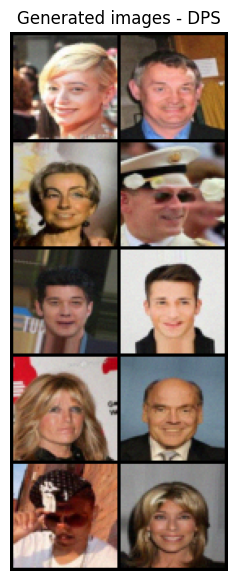

In [118]:
import torchvision

nrow = 2

# grid = torchvision.utils.make_grid(images[0][idx_img:idx_img+batch_size,:,:,:].cuda().cpu(), nrow=nrow, padding=2)
# grid_clean = grid.permute(1, 2, 0).numpy()

# grid = torchvision.utils.make_grid(x_init.cpu(), nrow=nrow, padding=2)
# grid_np = grid.permute(1, 2, 0).numpy()

# # Display the grid
# fig, ax = plt.subplots(1, 2,figsize=(25, 25))# Adjust figure size as needed
# ax[0].imshow(grid_clean)
# ax[0].axis('off') # Hide axes
# ax[1].imshow(grid_np)
# ax[1].axis('off') # Hide axes
# plt.savefig("samples.pdf")
# plt.show()

samples = torch.clamp(x[0], 0.0, 1.0)
grid = torchvision.utils.make_grid(samples, nrow=nrow, padding=2, normalize=False)
grid_np = grid.permute(1, 2, 0).numpy()

# Display the grid
plt.figure(figsize=(7, 7)) # Adjust figure size as needed
plt.imshow(grid_np)
plt.axis('off') # Hide axes
plt.title("Generated images - DPS")
plt.savefig("samples_DPS.pdf")
plt.show()
# plt.savefig("half_mask_samples

In [ ]:
def DPS_sampler(x_mod, y, H, mask, scorenet, sigmas, n_steps_each=200, batch_size=1,
               inp_mask_type="half", box_size=12, temp=1, snr=0.1):
    var_clean = 0
    iter_print_img = 0
    
    for c, sigma in enumerate(sigmas[:-2]):
        sigma_curr = sigmas[c]
        sigma_next = sigmas[c+1]
        
        # KEY FIX 1: Enable gradients only on x_mod, not intermediate tensors
        x_mod = x_mod.detach().requires_grad_(True)
        
        covariance = [spatial_corr_covariance_testing(
            spatial_size=H, box_size=box_size, var_box=sigma_curr**2, 
            device=device, var_clean=sigma_curr**2, 
            inp_mask_type=inp_mask_type, half_box_size=box_size
        )] * batch_size
        # covariance = [deblurring_covariance_from_shape(spatial_size=H, kernel_size=kernel_size, kernel_std=kernel_std, device=device, noise_level=sigma_curr**2)] * batch_size
        
        noise_level = NoiseLevel(variance=sigma_curr**2)
        input = ModelInput(noisy=x_mod, noise_level=noise_level, covariance=covariance)
        
        # KEY FIX 2: Forward pass with gradient tracking
        model_output = scorenet.forward(input, create_graph=False)
        grad = -model_output.data_score
        x0_pred = model_output.denoised
        
        # KEY FIX 3: Compute gradient efficiently
        residual = y - mask.apply_power(x0_pred, p=1)
        mat_norm = (residual.reshape(batch_size, -1) ** 2).sum(dim=1).sqrt()
        mat = (residual.reshape(batch_size, -1) ** 2).sum()
        
        # Compute gradient w.r.t. x_mod directly (backprop through network)
        grad_term = torch.autograd.grad(mat, x_mod, retain_graph=False)[0]
        
        # KEY FIX 4: Detach everything immediately after gradient computation
        grad = grad.detach()
        grad_term = grad_term.detach()
        mat_norm = mat_norm.detach()
        coeff = 0.1 / mat_norm.reshape(-1, 1, 1, 1)
        
        # KEY FIX 5: Move to no_grad context for update step
        with torch.no_grad():
            diff = sigma_curr**2 - sigma_next**2
            noise = torch.randn_like(x_mod)
            x_mod = x_mod + diff * grad + torch.sqrt(diff) * noise - coeff * grad_term
        
        # KEY FIX 6: Clear cache periodically
        if c % 10 == 0:  # Every 10 steps
            torch.cuda.empty_cache()
        
        # Visualization code (unchanged)
        if iter_print_img % 200 == 0:
            with torch.no_grad():
                samples = torch.clamp(x_mod, 0.0, 1.0)
                nrow = 5
                grid = torchvision.utils.make_grid(samples[0:20], nrow=nrow, 
                                                  padding=2, normalize=False)
                grid_np = grid.permute(1, 2, 0).cpu().numpy()
                plt.figure(figsize=(5, 5))
                plt.imshow(grid_np)
                plt.axis('off')
                plt.title("Generated images - Energy")
                plt.show()
        iter_print_img += 1
    
    return [x_mod.detach().to('cpu')]
    


sigma_begin = 30
num_classes = 1000
sigma_dist = 'geometric'
sigma_end = 1e-2
img_size = H
batch_size = 1
sigma_box_init = sigma_begin**2
sigma_clean_init = 1e-7
inp_mask_type = "box"
box_size = 10#19

sigmas = get_sigmas(sigma_begin, sigma_end, num_classes, device, sigma_dist)


idx_img = 0 #torch.randint(0, images[0].shape[0], (1,)).item()
cov = spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=0, device=device, var_clean = 1, half_box_size = box_size, inp_mask_type=inp_mask_type)
x_init = cov.apply_power(images[0][idx_img:idx_img+batch_size,:,:,:].cuda(), p = 1) + 1e-7 * torch.randn_like(images[0][idx_img:idx_img+batch_size,:,:,:]).cuda()
y = x_init[0:batch_size]

# kernel_size = 8
# kernel_std = 0.8
# deblurring_id = deblurring_covariance_from_shape(spatial_size=H, kernel_size=kernel_size, kernel_std=kernel_std, device=device, noise_level=1)
# # deblurring_id = sr_covariance_from_shape(spatial_size=H, kernel_size=4, device=device, noise_level=1)
# idx_img = 0 #torch.randint(0, images[0].shape[0], (1,)).item()
# x_deblur = deblurring_id.apply_power(images[0][idx_img:idx_img+batch_size,:,:,:].cuda(), p = -0.5)
# x_init = x_deblur + 1e-4 * torch.randn_like(images[0][0:batch_size,:,:,:]).cuda()
# y = x_init[0:batch_size]

# x_init = torch.randn_like(images[0][0:batch_size,:,:,:]).cuda()

Testing with 64x64 resolution
num_boxes=   1 → box_size=64x64, placed   1 boxes
num_boxes=   4 → box_size=32x32, placed   4 boxes
num_boxes=  16 → box_size=16x16, placed  16 boxes
num_boxes=  64 → box_size= 8x 8, placed  64 boxes
num_boxes= 256 → box_size= 4x 4, placed 256 boxes
num_boxes=1024 → box_size= 2x 2, placed 1024 boxes


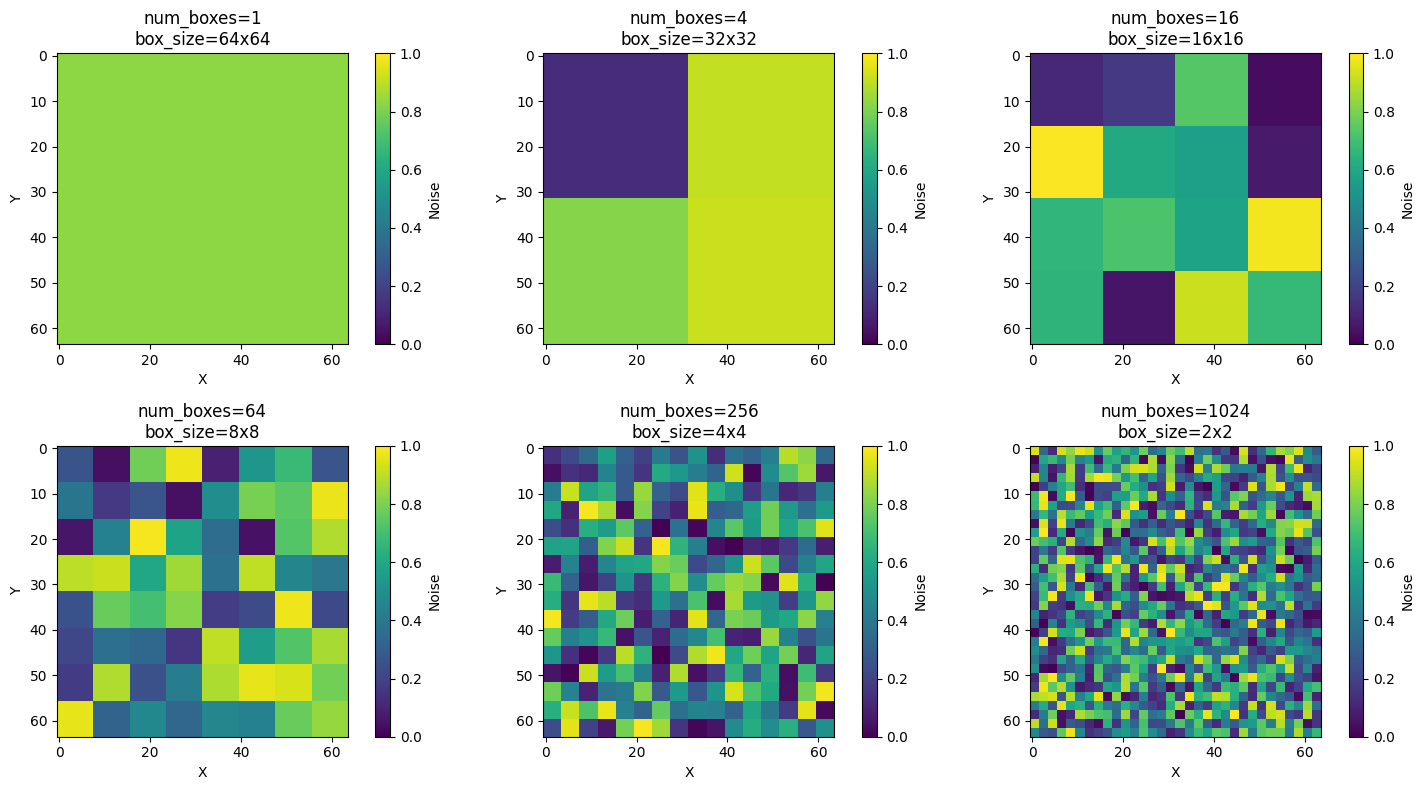


BATCH PROCESSING EXAMPLE
Output shape: torch.Size([4, 64, 64])
Batch size: 4, num_boxes: 16


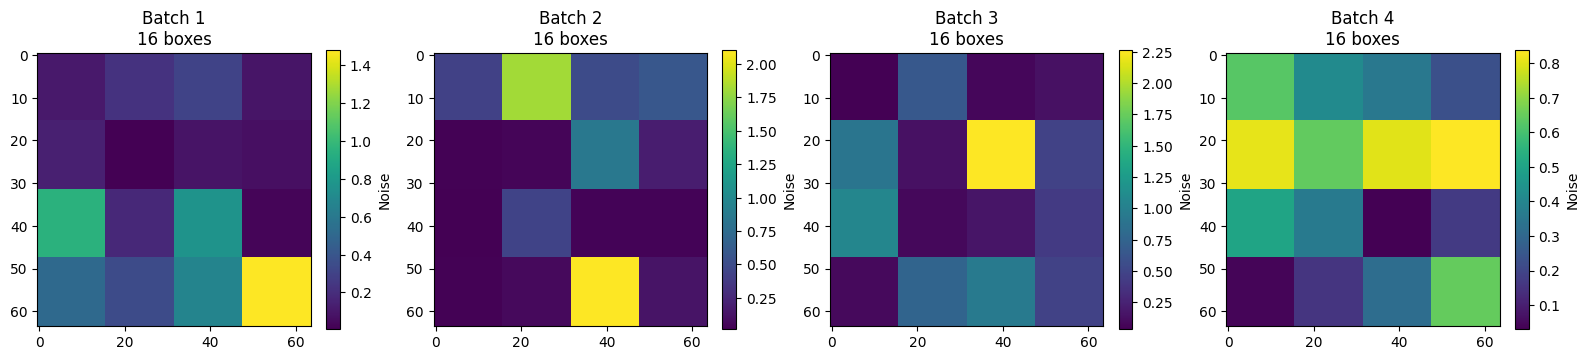


NUM_BOXES → GRANULARITY MAPPING
 num_boxes |   box_size |                    description
------------------------------------------------------------
         1 |         64 |     Whole image (global noise)
         2 |         64 |                      ~1x1 grid
         3 |         64 |                      ~1x1 grid
         4 |         32 |                      ~2x2 grid
         9 |         21 |                      ~3x3 grid
        16 |         16 |                      ~4x4 grid
        49 |          9 |                      ~7x7 grid
       196 |          4 |                    ~14x14 grid
       784 |          2 |                Per-pixel noise


In [86]:
import torch
import matplotlib.pyplot as plt

def build_dynamic_noise_mask(spatial_size, num_boxes, noise_levels, device, overlap_mode='max'):
    """
    Build a spatial noise mask where each box gets its own noise level.
    
    Args:
        spatial_size: Size of the square spatial dimension (e.g., 28 for MNIST)
        num_boxes: Number of boxes to partition the image
                   - num_boxes = 1: whole image gets same noise level
                   - num_boxes = spatial_size: each pixel gets its own noise level
                   - in between: tiles/boxes of varying sizes
        noise_levels: Tensor of shape (num_boxes,) with noise variance for each box
        device: PyTorch device
        overlap_mode: 'max', 'sum', or 'non_overlap' (default: 'max')
    
    Returns:
        noise_mask: 2D tensor of shape (spatial_size, spatial_size) with spatial noise variance map
        box_size: Size of each box used
        centers: List of (y, x) centers for each box
    """
    # Calculate box size based on num_boxes
    # Strategy: aim for approximately sqrt(num_boxes) boxes per row
    boxes_per_row = int(torch.sqrt(torch.tensor(num_boxes, dtype=torch.float32)).item())
    boxes_per_row = max(1, min(boxes_per_row, spatial_size))
    
    box_size = spatial_size // boxes_per_row
    box_size = max(1, box_size)
    
    # Adjust num_boxes to match actual grid capacity
    actual_max_boxes = boxes_per_row * boxes_per_row
    
    # Initialize noise mask with zeros
    noise_mask = torch.zeros((spatial_size, spatial_size), device=device)
    
    # Generate box centers
    if overlap_mode == 'non_overlap':
        # Grid-based placement for non-overlapping
        centers = []
        for i in range(boxes_per_row):
            for j in range(boxes_per_row):
                if len(centers) >= num_boxes:
                    break
                cy = i * box_size + box_size // 2
                cx = j * box_size + box_size // 2
                centers.append((cy, cx))
            if len(centers) >= num_boxes:
                break
    else:
        # Random placement for overlapping modes
        half_box = box_size // 2
        min_coord = half_box
        max_coord = spatial_size - half_box
        
        centers = []
        for _ in range(min(num_boxes, len(noise_levels))):
            cy = torch.randint(min_coord, max_coord, (1,), device=device).item()
            cx = torch.randint(min_coord, max_coord, (1,), device=device).item()
            centers.append((cy, cx))
    
    # Place each box with its corresponding noise level
    for idx, (cy, cx) in enumerate(centers):
        if idx >= len(noise_levels):
            break
            
        start_y = max(0, cy - box_size // 2)
        end_y = min(spatial_size, start_y + box_size)
        start_x = max(0, cx - box_size // 2)
        end_x = min(spatial_size, start_x + box_size)
        
        noise_level = noise_levels[idx].item()
        
        if overlap_mode == 'max':
            noise_mask[start_y:end_y, start_x:end_x] = torch.maximum(
                noise_mask[start_y:end_y, start_x:end_x],
                torch.tensor(noise_level, device=device)
            )
        elif overlap_mode == 'sum':
            noise_mask[start_y:end_y, start_x:end_x] += noise_level
        else:  # non_overlap
            noise_mask[start_y:end_y, start_x:end_x] = noise_level
    
    return noise_mask, box_size, centers


def sample_and_build_noise_mask(batch_size, spatial_size, num_boxes, device, 
                                 noise_sampler=None, overlap_mode='max'):
    """
    Complete pipeline: sample noise levels and build spatial mask.
    
    Args:
        batch_size: Batch size
        spatial_size: Spatial dimension (e.g., 28)
        num_boxes: Number of boxes per image
        device: PyTorch device
        noise_sampler: Function that samples noise levels, if None uses uniform [0, 1]
        overlap_mode: 'max', 'sum', or 'non_overlap'
    
    Returns:
        noise_masks: Tensor of shape (batch_size, spatial_size, spatial_size)
        box_info: List of (box_size, centers) for each batch item
    """
    noise_masks = []
    box_info = []
    
    for b in range(batch_size):
        # Sample noise levels for this image's boxes
        if noise_sampler is not None:
            noise_levels = noise_sampler(torch.Size([num_boxes]), device=device)
        else:
            # Default: uniform sampling
            noise_levels = torch.rand(num_boxes, device=device)
        
        # Build spatial mask
        mask, box_size, centers = build_dynamic_noise_mask(
            spatial_size, num_boxes, noise_levels, device, overlap_mode
        )
        
        noise_masks.append(mask)
        box_info.append((box_size, centers))
    
    noise_masks = torch.stack(noise_masks, dim=0)
    return noise_masks, box_info


# Example usage and visualization
if __name__ == "__main__":
    spatial_size = 64
    device = 'cpu'
    batch_size = 1
    
    # Test different num_boxes values
    test_cases = [1, 4, 16, 64, 256, 1024, 4096]#[1, 4, 16, 49, 196, 784]  # 784 = 28*28 (per-pixel)
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    
    print("=" * 60)
    print(f"Testing with {spatial_size}x{spatial_size} resolution")
    print("=" * 60)
    
    for idx, num_boxes in enumerate(test_cases):
        if idx >= len(axes):
            break
        
        # Sample noise levels
        noise_levels = torch.rand(num_boxes, device=device)
        
        # Build mask
        mask, box_size, centers = build_dynamic_noise_mask(
            spatial_size=spatial_size,
            num_boxes=num_boxes,
            noise_levels=noise_levels,
            device=device,
            overlap_mode='non_overlap'
        )
        
        # Visualize
        im = axes[idx].imshow(mask.numpy(), cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
        axes[idx].set_title(f'num_boxes={num_boxes}\nbox_size={box_size}x{box_size}')
        axes[idx].set_xlabel('X')
        axes[idx].set_ylabel('Y')
        plt.colorbar(im, ax=axes[idx], label='Noise', fraction=0.046)
        plt.tight_layout()
        plt.savefig("Boxes.pdf")
        
        print(f"num_boxes={num_boxes:4d} → box_size={box_size:2d}x{box_size:2d}, placed {len(centers):3d} boxes")
    
    # Hide extra subplot
    if len(test_cases) < len(axes):
        axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Demonstrate batch processing
    print("\n" + "=" * 60)
    print("BATCH PROCESSING EXAMPLE")
    print("=" * 60)
    
    batch_size = 4
    num_boxes = 16
    
    # Custom noise sampler example (exponential distribution)
    def exponential_noise_sampler(shape, device):
        return torch.distributions.Exponential(rate=2.0).sample(shape).to(device)
    
    noise_masks, box_info = sample_and_build_noise_mask(
        batch_size=batch_size,
        spatial_size=spatial_size,
        num_boxes=num_boxes,
        device=device,
        noise_sampler=exponential_noise_sampler,
        overlap_mode='non_overlap'
    )
    
    print(f"Output shape: {noise_masks.shape}")
    print(f"Batch size: {batch_size}, num_boxes: {num_boxes}")
    
    # Visualize batch
    fig, axes = plt.subplots(1, batch_size, figsize=(4*batch_size, 4))
    for b in range(batch_size):
        im = axes[b].imshow(noise_masks[b].numpy(), cmap='viridis', interpolation='nearest')
        box_size, centers = box_info[b]
        axes[b].set_title(f'Batch {b+1}\n{len(centers)} boxes')
        plt.colorbar(im, ax=axes[b], label='Noise', fraction=0.046)
    
    plt.tight_layout()
    plt.show()
    
    # Show the relationship: num_boxes → coverage
    print("\n" + "=" * 60)
    print("NUM_BOXES → GRANULARITY MAPPING")
    print("=" * 60)
    print(f"{'num_boxes':>10} | {'box_size':>10} | {'description':>30}")
    print("-" * 60)
    for nb in [1, 2, 3, 4, 9, 16, 49, 196, 784]:
        boxes_per_row = int(torch.sqrt(torch.tensor(nb, dtype=torch.float32)).item())
        box_size = spatial_size // boxes_per_row
        if nb == 1:
            desc = "Whole image (global noise)"
        elif nb == 784:
            desc = "Per-pixel noise"
        else:
            desc = f"~{boxes_per_row}x{boxes_per_row} grid"
        print(f"{nb:>10} | {box_size:>10} | {desc:>30}")